In [73]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')

In [74]:
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

In [75]:
data = pd.read_csv('insurance.csv')

# EDA 

In [76]:
data.shape

(1338, 7)

In [77]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [78]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [79]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [80]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [81]:
numeric_cols = data.select_dtypes(include=np.number).columns
numeric_cols

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

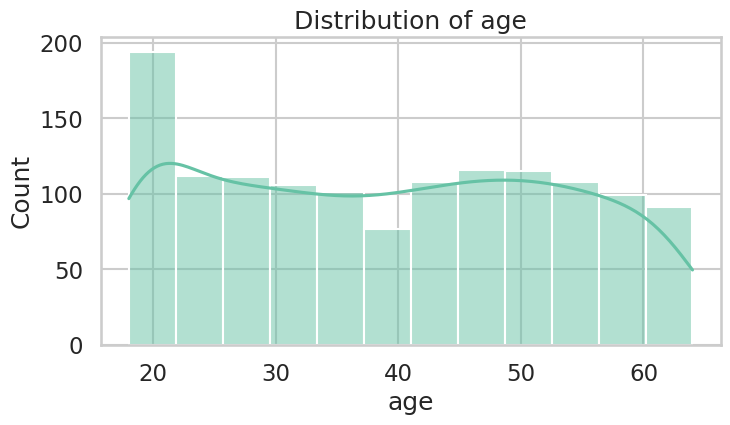

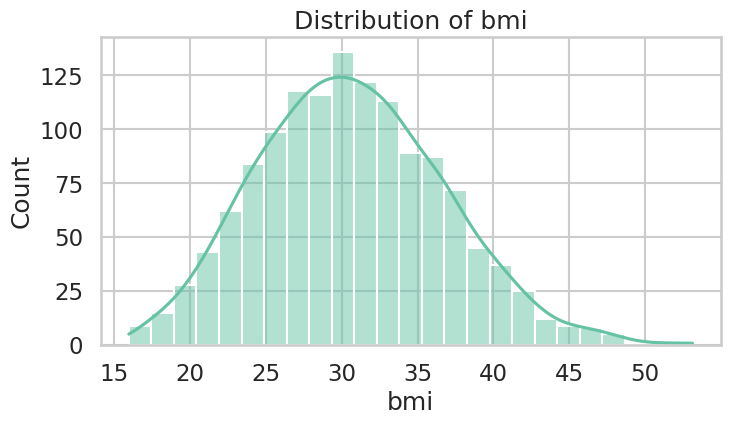

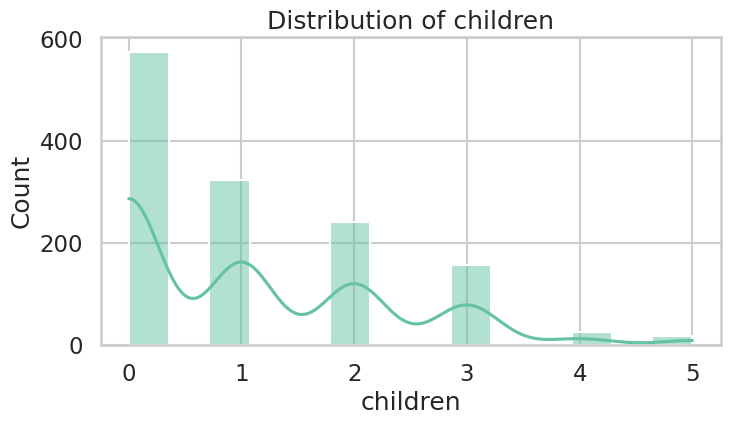

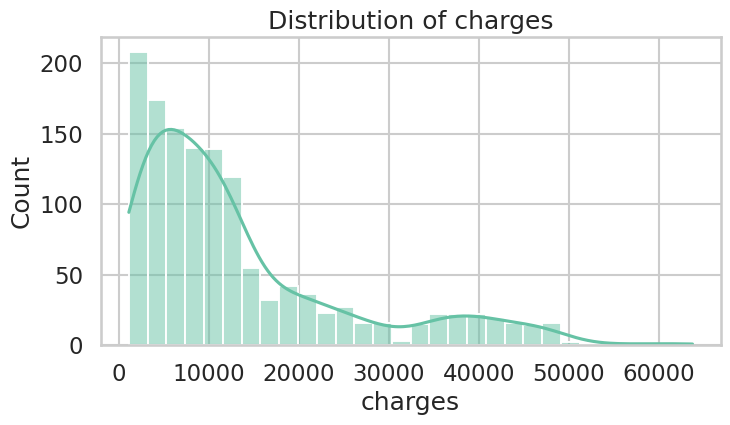

In [82]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: xlabel='children', ylabel='count'>

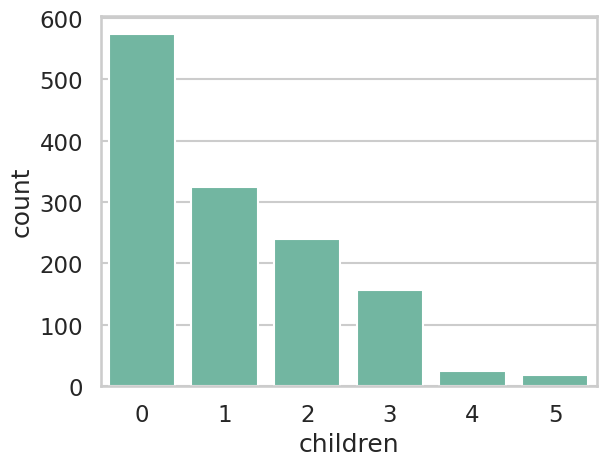

In [83]:
sns.countplot(x = data['children'])

<Axes: xlabel='sex', ylabel='count'>

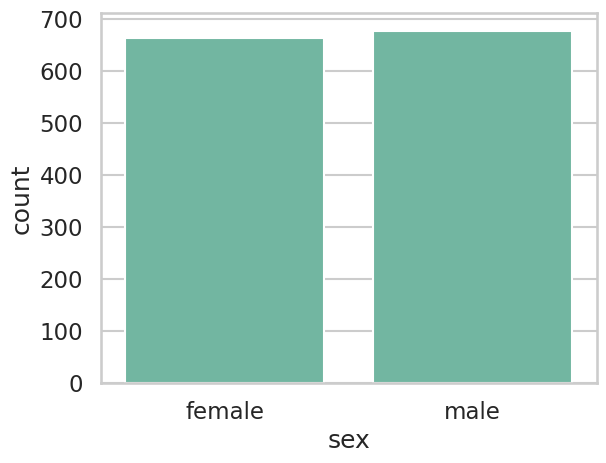

In [84]:
sns.countplot(x= data['sex'])

<Axes: xlabel='smoker', ylabel='count'>

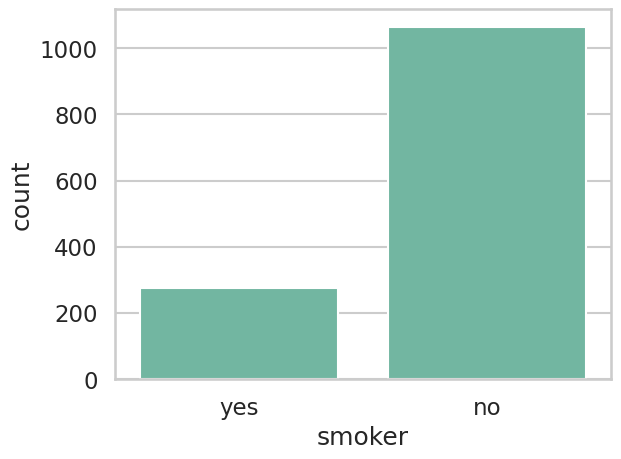

In [85]:
sns.countplot(x= data['smoker'])

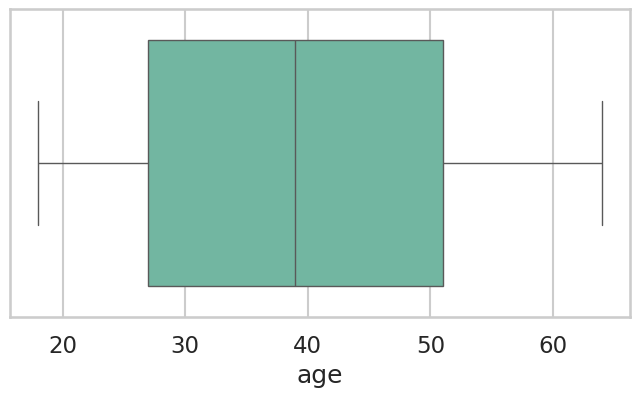

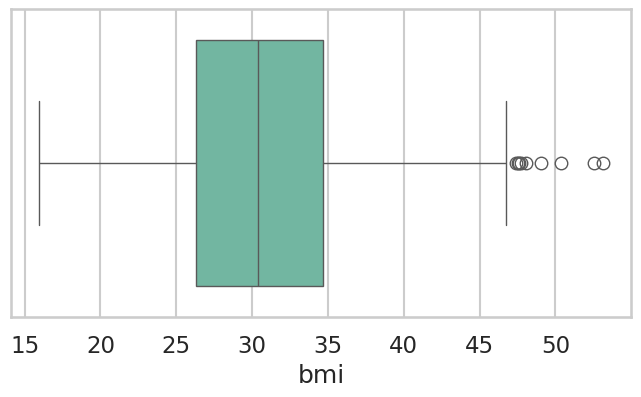

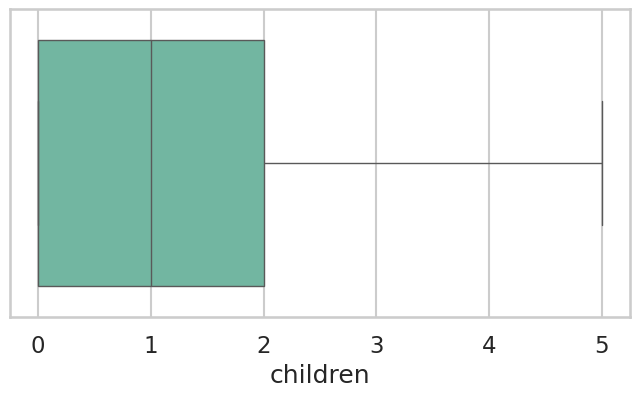

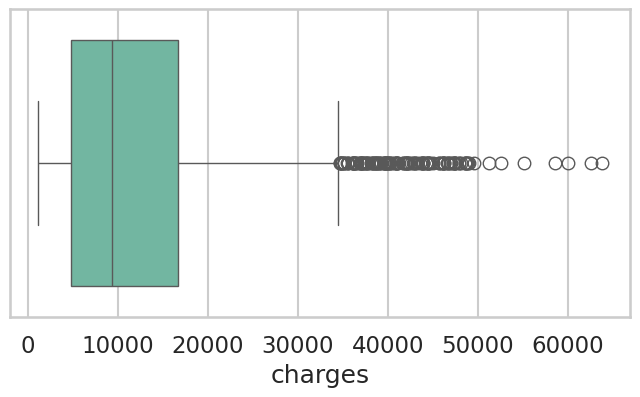

In [86]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x = data[col])
    plt.show()

<Axes: >

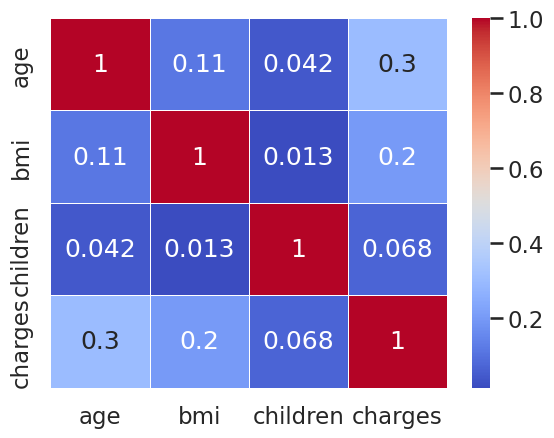

In [87]:
sns.heatmap(data.corr(numeric_only = True), annot=True, cmap='coolwarm', linewidths=0.5)

# Data Cleaning and preprocessing 

In [88]:
data_cleaned = data.copy()

In [89]:
data_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [90]:
data_cleaned.drop_duplicates(inplace=True)

In [91]:
data_cleaned.shape

(1337, 7)

In [92]:
data_cleaned.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [93]:
data_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [94]:
data_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [95]:
data_cleaned['sex'] = data_cleaned['sex'].map({'male': 0, 
                                               'female': 1}, inplace = True)

In [96]:
data_cleaned.rename(columns = {'sex': 'is_female'} , inplace = True)

In [97]:
data_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [98]:
data_cleaned['smoker'] = data_cleaned['smoker'].map({'no': 0,
                                                   'yes': 1}, inplace = True)

In [99]:
data_cleaned.rename(columns = {'smoker': 'is_smoker'} , inplace = True)

In [100]:
data_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [101]:
data_cleaned = pd.get_dummies(data_cleaned,columns= ['region'], prefix='region',  dtype = int)

In [102]:
data_cleaned 

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0
1334,18,1,31.920,0,0,2205.98080,1,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,0,1


In [103]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0


# Feature Engineering and Extraction

In [104]:
data_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0
1334,18,1,31.920,0,0,2205.98080,1,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,0,1


In [105]:
data_cleaned['bmi_category'] = pd.cut(data_cleaned['bmi'], bins=[0, 18.5, 25, 30, np.inf], labels=['Underweight', 'Normal weight', 'Overweight', 'Obese'])

In [106]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0,0,1,0,Obese
2,28,0,33.000,3,0,4449.46200,0,0,1,0,Obese
3,33,0,22.705,0,0,21984.47061,0,1,0,0,Normal weight
4,32,0,28.880,0,0,3866.85520,0,1,0,0,Overweight


In [107]:
data_cleaned = pd.get_dummies(data_cleaned,columns= ['bmi_category'], prefix='bmi_category', dtype = int)

In [108]:
data_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0


# Test train split

In [109]:
from sklearn.model_selection import train_test_split

In [110]:
X = data_cleaned.drop('charges', axis=1)
y = data_cleaned['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# feature scaling

**Using library**

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_scale = ['age', 'bmi', 'children']

X_train[cols_scale] = scaler.fit_transform(X_train[cols_scale])
X_test[cols_scale] = scaler.transform(X_test[cols_scale])

In [112]:
data_cleaned.corr(numeric_only = True)

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese
age,1.000000,0.019814,0.109344,0.041536,-0.025587,0.298308,0.001868,0.001495,-0.012311,0.009415,-0.061557,-0.074800,-0.018075,0.087881
is_female,0.019814,1.000000,-0.046397,-0.017848,-0.076596,-0.058044,0.002008,0.012482,-0.017578,0.003767,0.031307,0.024343,0.019400,-0.043676
bmi,0.109344,-0.046397,1.000000,0.012755,0.003746,0.198401,-0.138178,-0.136138,0.270057,-0.006211,-0.270385,-0.592272,-0.317070,0.799681
children,0.041536,-0.017848,0.012755,1.000000,0.007331,0.067389,-0.023202,0.026044,-0.023492,0.021538,-0.005044,0.010538,-0.020481,0.011935
is_smoker,-0.025587,-0.076596,0.003746,0.007331,1.000000,0.787234,0.002597,-0.036321,0.068282,-0.037168,0.010377,0.018216,-0.016787,-0.001021
charges,0.298308,-0.058044,0.198401,0.067389,0.787234,1.000000,0.005945,-0.038695,0.073578,-0.043637,-0.048225,-0.105946,-0.120059,0.200501
region_northeast,0.001868,0.002008,-0.138178,-0.023202,0.002597,0.005945,1.000000,-0.319842,-0.345909,-0.320493,0.068942,0.084916,0.017176,-0.096498
region_northwest,0.001495,0.012482,-0.136138,0.026044,-0.036321,-0.038695,-0.319842,1.000000,-0.345909,-0.320493,0.026827,0.038343,0.051843,-0.082515
region_southeast,-0.012311,-0.017578,0.270057,-0.023492,0.068282,0.073578,-0.345909,-0.345909,1.000000,-0.346614,-0.077264,-0.092040,-0.093030,0.172763
region_southwest,0.009415,0.003767,-0.006211,0.021538,-0.037168,-0.043637,-0.320493,-0.320493,-0.346614,1.000000,-0.015492,-0.027619,0.027591,-0.000452


# Pearsonr correlation and Chi - squared test for feature selection

In [113]:
from scipy.stats import pearsonr

targeted_cols = ['age', 'bmi', 'children', 
                 'is_female', 'is_smoker', 'region_northwest',
                 'region_southeast', 'region_southwest', 'bmi_category_Normal weight', 
                 'bmi_category_Overweight', 'bmi_category_Obese']

correlation = {
    feature : pearsonr(X_train[feature], y_train)[0] 
    for feature in targeted_cols
}

correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Correlation with Charges'])
correlation_df.sort_values(by='Correlation with Charges', ascending=False)


,Feature,Correlation with Charges
4,is_smoker,0.774131
0,age,0.289691
10,bmi_category_Obese,0.193465
1,bmi,0.178440
2,children,0.086172
6,region_southeast,0.078927
7,region_southwest,-0.036003
5,region_northwest,-0.054955
3,is_female,-0.060167
8,bmi_category_Normal weight,-0.093206


**Mutual-info-classif**

In [114]:
data_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight',
       'bmi_category_Normal weight', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='str')

In [115]:
from sklearn.feature_selection import mutual_info_regression
features = [
    'age', 'is_female', 'bmi', 'children', 'is_smoker',
    'region_northeast', 'region_northwest',
    'region_southeast', 'region_southwest',
    'bmi_category_Underweight',
    'bmi_category_Normal weight',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]

mi_scores = mutual_info_regression(
    X_train[features],
    y_train,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": features,
    "Mutual Information Score": mi_scores
})

mi_results = mi_results.sort_values(
    by="Mutual Information Score",
    ascending=False
).reset_index(drop=True)

mi_results
    


,Feature,Mutual Information Score
0,age,1.441316
1,is_smoker,0.350576
2,children,0.158219
3,is_female,0.137112
4,bmi_category_Obese,0.105239
5,bmi,0.074661
6,region_northeast,0.047121
7,bmi_category_Overweight,0.046472
8,region_northwest,0.042278
9,bmi_category_Normal weight,0.033573


# Visualization of Mutual info score

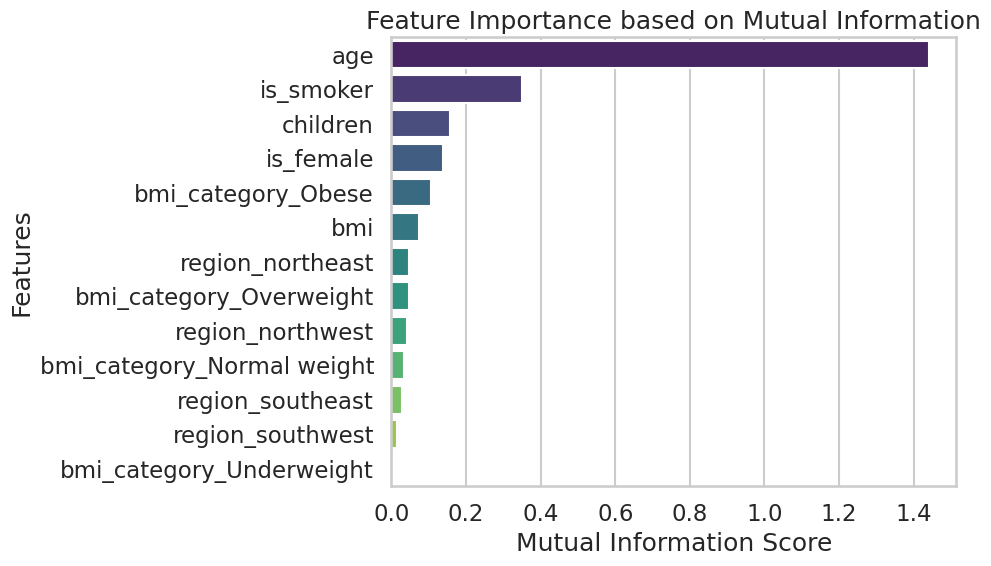

In [116]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_results,
    x="Mutual Information Score",
    y="Feature",
    palette="viridis"
    
)

plt.title("Feature Importance based on Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

**Going with all the features for first model**

In [117]:
# X_train = X_train[['age','is_smoker','children','is_female','bmi_category_Obese','bmi']]
# X_test = X_test[['age','is_smoker','children','is_female','bmi_category_Obese','bmi']]

# Models 

In [118]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score, root_mean_squared_error, mean_absolute_error
)

In [119]:
models = {
    "LinearRegression" : LinearRegression(),
    "DT": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor(n_neighbors=7),
    "Forest": RandomForestRegressor(n_estimators=1500)
}

In [120]:
results = {}
for name,model in models.items():
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    results[name] = pred  
    
print(results) 

{'LinearRegression': array([ 8.27594475e+03,  5.15852242e+03,  1.45510994e+04,  3.25017096e+04,
        8.92287539e+03,  1.33042575e+04,  3.06660988e+04,  1.07260377e+03,
        1.12384126e+04,  9.95338674e+03,  1.07567578e+04,  3.20749075e+04,
        3.20814581e+04,  1.56166779e+04,  1.06356325e+04,  8.15544306e+03,
        5.27020957e+03,  3.24937375e+04,  3.02479779e+03,  3.85858428e+03,
        4.86100564e+03,  2.91679254e+04,  1.37065623e+04,  2.91931292e+04,
        3.15256538e+04,  6.44052026e+03,  3.49130288e+04,  3.76616998e+04,
        1.30807232e+04,  1.46868751e+04,  8.12348286e+03,  1.29848758e+04,
        5.47913974e+02,  1.09924178e+04,  3.72472560e+04,  1.30609332e+04,
        3.42307477e+03,  4.65404269e+03,  3.15644180e+04,  7.95112662e+03,
        6.46470314e+03,  3.08651368e+04,  3.53443403e+04,  1.36002381e+04,
        8.06100662e+03,  2.77388754e+03,  5.50897107e+03,  7.27251406e+03,
        3.59495086e+03,  1.05075025e+04,  7.90880562e+03,  1.07676000e+04,
    

# models evaluation

In [121]:
model_evaluation = {}

for name, pred in results.items():
    r2 = r2_score(y_test,pred)
    n = len(y_test)    
    p = X_test.shape[1]
    adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    
    model_evaluation[name] = [r2,adjusted_r2,mae,rmse]
    
    
model_evaluation_df = pd.DataFrame(model_evaluation,index=['r2','adjusted_r2','mae','rmse'])
model_evaluation_df

,LinearRegression,DT,KNN,Forest
r2,0.802517,0.802291,0.561290,0.883131
adjusted_r2,0.792410,0.792172,0.538837,0.877150
mae,4338.923817,2742.099861,5532.465446,2583.368173
rmse,6024.004673,6027.453431,8978.616749,4634.153821


# Saving the model 

In [ ]:
import joblib as jl
jl.dump(scaler, 'scalar.pkl')
jl.dump(X.columns, 'columns.pkl')
jl.dump(cols_scale,'columns_to_scale.pkl')

['columns_to_scale.pkl']

In [123]:
jl.dump(models['Forest'], 'model.pkl')

['model.pkl']